In [27]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../../dataset/HDFS_v1/preprocessed/Event_traces.csv")
df = df[['Features']]

In [4]:
def convert_events(sequence):
    sequence = sequence.replace('[','').replace(']','')
    events = sequence.split(',')
    events = [int(re.sub('[^0-9]', '', e)) for e in events]
    return events
df['event_seq'] = df['Features'].apply(convert_events)

In [5]:
X = []
y = []
for seq in df['event_seq']:
    for i in range(1, len(seq)):
        X.append(seq[:i])
        y.append(seq[i])

In [6]:
max_len = 10
def pad_sequence(seq, max_len):
    if len(seq) < max_len:
        seq = [0]*(max_len-len(seq)) + seq
    else:
        seq = seq[-max_len:]
    return seq
X = [pad_sequence(seq, max_len) for seq in X]
X = np.array(X)
y = np.array(y)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
class LogDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
train_dataset = LogDataset(X_train, y_train)
test_dataset = LogDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128)

In [9]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size=30, embed_dim=32, hidden_dim=64):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)
    def forward(self, x):
        x = self.embedding(x)
        _, (h, _) = self.lstm(x)
        out = self.fc(h[-1])
        return out
model = LSTMModel()

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [11]:
epochs = 10
train_losses = []
test_losses = []
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    train_losses.append(total_loss/len(train_loader))

    model.eval()
    test_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            test_loss += loss.item()
    test_losses.append(test_loss/len(test_loader))
    print(f"Epoch {epoch+1}, Train Loss: {train_losses[-1]:.4f}, Test Loss: {test_losses[-1]:.4f}")

Epoch 1, Train Loss: 0.2292, Test Loss: 0.2210
Epoch 2, Train Loss: 0.2200, Test Loss: 0.2197
Epoch 3, Train Loss: 0.2192, Test Loss: 0.2196
Epoch 4, Train Loss: 0.2187, Test Loss: 0.2189
Epoch 5, Train Loss: 0.2185, Test Loss: 0.2185
Epoch 6, Train Loss: 0.2183, Test Loss: 0.2185
Epoch 7, Train Loss: 0.2182, Test Loss: 0.2180
Epoch 8, Train Loss: 0.2181, Test Loss: 0.2181
Epoch 9, Train Loss: 0.2180, Test Loss: 0.2186
Epoch 10, Train Loss: 0.2179, Test Loss: 0.2185


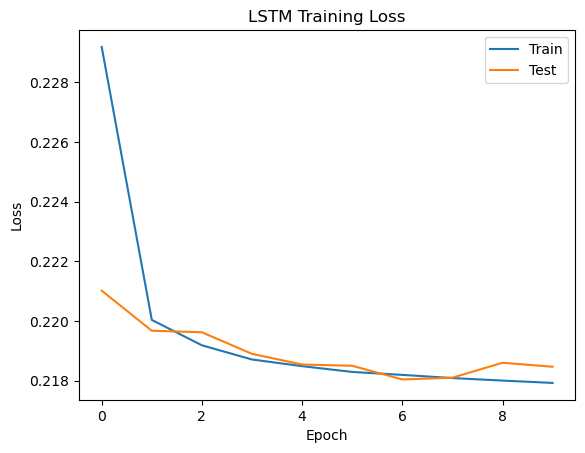

In [ ]:
plt.figure()

plt.plot(train_losses)
plt.plot(test_losses)

plt.title("LSTM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train","Test"])
plt.show()

In [ ]:
correct = 0
total = 0

model.eval()
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()
accuracy = 100 * correct / total

print("Test Accuracy:", accuracy)

Test Accuracy: 91.33928647233121


In [35]:
'''Working on 2200k dataset------->>'''

'Working on 2200k dataset------->>'

In [ ]:
#Loading Dataset
import pandas as pd

df = pd.read_csv("../../dataset/HDFS_v1/preprocessed/Event_traces.csv")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nFirst 5 rows:")
print(df.head())

Dataset shape: (575061, 6)

Columns:
Index(['BlockId', 'Label', 'Type', 'Features', 'TimeInterval', 'Latency'], dtype='object')

First 5 rows:
                    BlockId    Label  Type  \
0  blk_-1608999687919862906  Success   NaN   
1   blk_7503483334202473044  Success   NaN   
2  blk_-3544583377289625738     Fail  21.0   
3  blk_-9073992586687739851  Success   NaN   
4   blk_7854771516489510256  Success   NaN   

                                            Features  \
0  [E5,E22,E5,E5,E11,E11,E9,E9,E11,E9,E26,E26,E26...   
1  [E5,E5,E22,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...   
2  [E5,E22,E5,E5,E11,E9,E11,E9,E11,E9,E3,E26,E26,...   
3  [E5,E22,E5,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...   
4  [E5,E5,E22,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...   

                                        TimeInterval  Latency  
0  [0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...     3802  
1  [0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...     3802  
2  [0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ..

In [20]:
#Keeping Only Feature Column
df = pd.read_csv(
    "../../dataset/HDFS_v1/preprocessed/Event_traces.csv",
    usecols=["Features"],
    nrows=100000
)
print("After selecting Features column:")
print(df.head())

After selecting Features column:
                                            Features
0  [E5,E22,E5,E5,E11,E11,E9,E9,E11,E9,E26,E26,E26...
1  [E5,E5,E22,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...
2  [E5,E22,E5,E5,E11,E9,E11,E9,E11,E9,E3,E26,E26,...
3  [E5,E22,E5,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...
4  [E5,E5,E22,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...


In [ ]:
#Converting Events to Numbers
import re

def convert_events(sequence):

    sequence = sequence.replace('[','').replace(']','')
    events = sequence.split(',')
    events = [int(re.sub('[^0-9]', '', e)) for e in events]
    return events

df['event_seq'] = df['Features'].apply(convert_events)
print("\nConverted sequences:")
print(df[['Features','event_seq']].head())


Converted sequences:
                                            Features  \
0  [E5,E22,E5,E5,E11,E11,E9,E9,E11,E9,E26,E26,E26...   
1  [E5,E5,E22,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...   
2  [E5,E22,E5,E5,E11,E9,E11,E9,E11,E9,E3,E26,E26,...   
3  [E5,E22,E5,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...   
4  [E5,E5,E22,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...   

                                           event_seq  
0  [5, 22, 5, 5, 11, 11, 9, 9, 11, 9, 26, 26, 26,...  
1  [5, 5, 22, 5, 11, 9, 11, 9, 11, 9, 26, 26, 26,...  
2  [5, 22, 5, 5, 11, 9, 11, 9, 11, 9, 3, 26, 26, ...  
3  [5, 22, 5, 5, 11, 9, 11, 9, 11, 9, 26, 26, 26,...  
4  [5, 5, 22, 5, 11, 9, 11, 9, 11, 9, 26, 26, 26,...  


In [ ]:
#Creating Next Event Prediction Samples
X = []
y = []

for seq in df['event_seq']:
    for i in range(1, len(seq)):
        X.append(seq[:i])
        y.append(seq[i])

print("Total training samples created:", len(X))
print("\nExample samples:")
for i in range(5):
    print("Input:", X[i], "Target:", y[i])

Total training samples created: 2248836

Example samples:
Input: [5] Target: 22
Input: [5, 22] Target: 5
Input: [5, 22, 5] Target: 5
Input: [5, 22, 5, 5] Target: 11
Input: [5, 22, 5, 5, 11] Target: 11


In [ ]:
#Padding Sequences
max_len = 10

def pad_sequence(seq, max_len):
    if len(seq) < max_len:
        seq = [0]*(max_len-len(seq)) + seq
    else:
        seq = seq[-max_len:]
    return seq
X = [pad_sequence(seq, max_len) for seq in X]
print("\nAfter padding:")
for i in range(5):
    print(X[i])


After padding:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 5]
[0, 0, 0, 0, 0, 0, 0, 0, 5, 22]
[0, 0, 0, 0, 0, 0, 0, 5, 22, 5]
[0, 0, 0, 0, 0, 0, 5, 22, 5, 5]
[0, 0, 0, 0, 0, 5, 22, 5, 5, 11]


In [24]:
#Convert to Numpy Arrays
import numpy as np

X = np.array(X)
y = np.array(y)

print("\nFinal dataset shapes:")
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nExample input vector:")
print(X[0])

print("Example label:")
print(y[0])


Final dataset shapes:
X shape: (2248836, 10)
y shape: (2248836,)

Example input vector:
[0 0 0 0 0 0 0 0 0 5]
Example label:
22


In [39]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [40]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1799068, 10)
Test shape: (449768, 10)


In [ ]:
#saving the dataset
np.save("X_train.npy", X_train)
np.save("y_train.npy", y_train)
np.save("X_test.npy", X_test)
np.save("y_test.npy", y_test)

In [42]:
X_train = np.load("X_train.npy")
y_train = np.load("y_train.npy")

In [ ]:
#Create PyTorch Datase
class LogDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
train_dataset = LogDataset(X_train, y_train)
test_dataset = LogDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128)

In [ ]:
#LSTM Model
class LSTMModel(nn.Module):
    def __init__(self, vocab_size=30, embed_dim=32, hidden_dim=64):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)
    def forward(self, x):
        x = self.embedding(x)
        _, (h, _) = self.lstm(x)
        out = self.fc(h[-1])
        return out
model = LSTMModel()

In [ ]:
#Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
#Training Loop
epochs = 5
train_losses = []
test_losses = []
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    train_losses.append(total_loss/len(train_loader))

    model.eval()
    test_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            test_loss += loss.item()
    test_losses.append(test_loss/len(test_loader))
    print(f"Epoch {epoch+1}, Train Loss: {train_losses[-1]:.4f}, Test Loss: {test_losses[-1]:.4f}")

Epoch 1, Train Loss: 0.2856, Test Loss: 0.2610
Epoch 2, Train Loss: 0.2557, Test Loss: 0.2578
Epoch 3, Train Loss: 0.2530, Test Loss: 0.2540
Epoch 4, Train Loss: 0.2517, Test Loss: 0.2533
Epoch 5, Train Loss: 0.2508, Test Loss: 0.2522


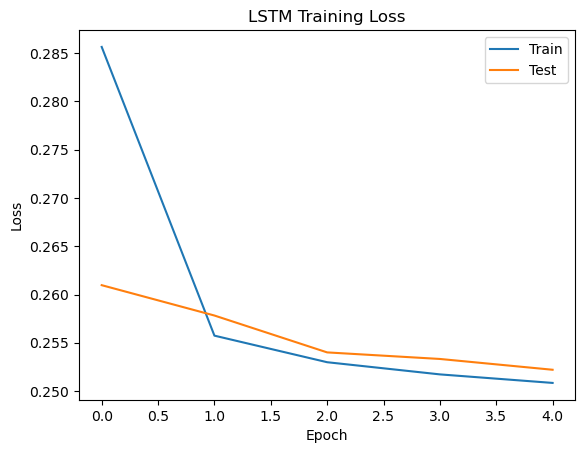

In [ ]:
#Plot Training Loss
plt.figure()

plt.plot(train_losses)
plt.plot(test_losses)

plt.title("LSTM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train","Test"])

plt.show()

In [ ]:
#Get Predictions from the Model
correct = 0
total = 0

model.eval()
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()
accuracy = 100 * correct / total
print("Test Accuracy:", accuracy)

Test Accuracy: 89.50881343270308


In [ ]:
#Getting Predictions from the Model
from sklearn.metrics import accuracy_score

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

print("Accuracy:", accuracy_score(all_labels, all_preds))

Accuracy: 0.8950881343270308


In [43]:
#Precision, Recall, F1-Score
from sklearn.metrics import classification_report
print(classification_report(all_labels, all_preds))


              precision    recall  f1-score   support

           2       0.65      0.55      0.60     11372
           3       0.76      0.79      0.77     47217
           4       0.79      0.70      0.74     38038
           5       0.94      1.00      0.97     54242
           6       0.78      0.36      0.49        50
           7       0.75      0.01      0.03       225
           9       0.99      0.98      0.99     58464
          10       0.67      0.67      0.67         3
          11       0.93      0.90      0.91     58495
          13       0.71      0.12      0.21        40
          14       1.00      0.75      0.86         4
          15       0.00      0.00      0.00         1
          16       0.69      0.80      0.74        41
          18       0.74      0.60      0.67        48
          20       1.00      0.40      0.57       261
          21       0.99      1.00      1.00     58864
          22       1.00      0.34      0.51      5082
          23       0.84    

/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


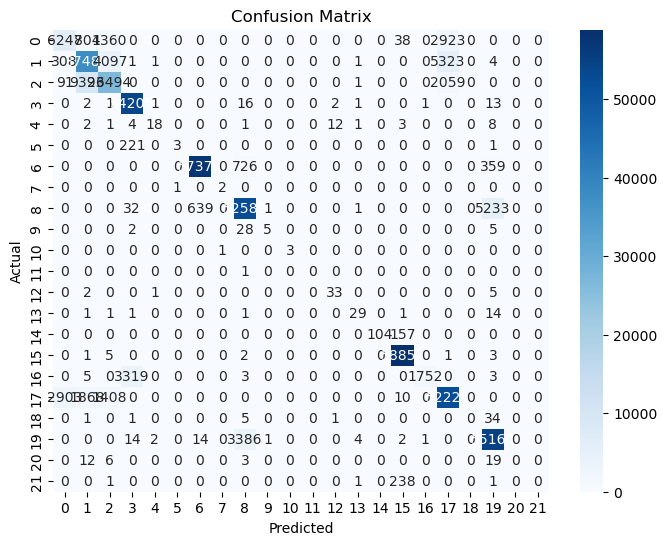

In [44]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

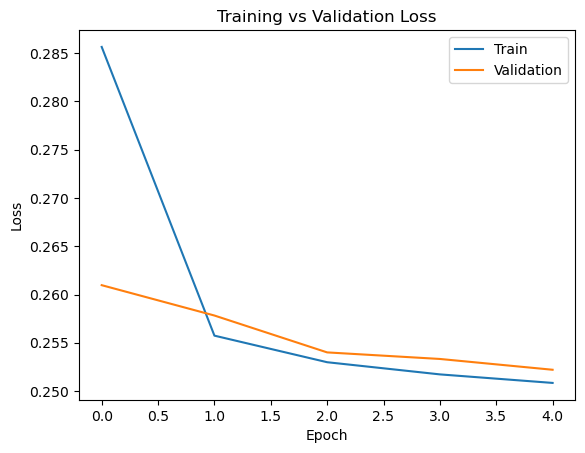

In [49]:
#Training Curves
plt.figure()

plt.plot(train_losses)
plt.plot(test_losses)

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.show()

/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packa

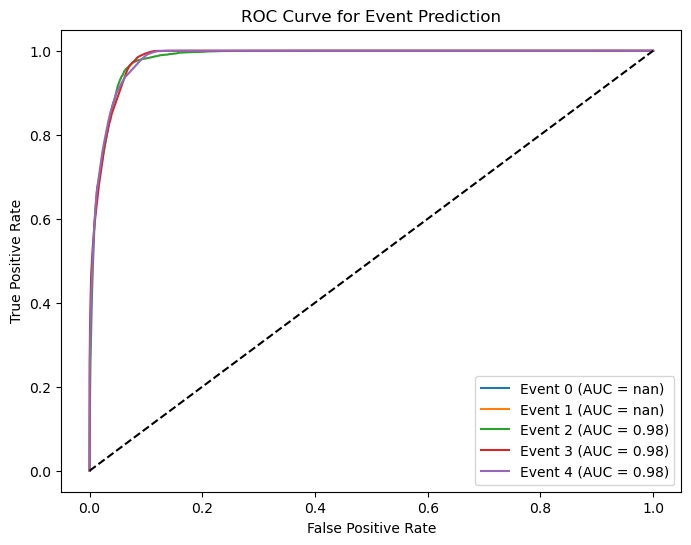

In [ ]:
#ROC Curve
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize


# Put model in evaluation mode
model.eval()

all_probs = []
all_labels = []

# Collect probabilities and true labels
with torch.no_grad():
    
    for X_batch, y_batch in test_loader:
        
        outputs = model(X_batch)
        
        # Convert logits to probabilities
        probs = F.softmax(outputs, dim=1)
        
        all_probs.append(probs.cpu().numpy())
        all_labels.append(y_batch.cpu().numpy())


# Combine batches
all_probs = np.vstack(all_probs)
all_labels = np.concatenate(all_labels)


# Number of event classes (E1–E29)
num_classes = 30


# Convert labels to one-hot format
y_true = label_binarize(all_labels, classes=list(range(num_classes)))


# Calculate ROC for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(num_classes):
    
    fpr[i], tpr[i], _ = roc_curve(y_true[:, i], all_probs[:, i])
    
    roc_auc[i] = auc(fpr[i], tpr[i])


# Plot ROC curves
plt.figure(figsize=(8,6))

for i in range(5):  # plotting first 5 classes to keep graph readable
    
    plt.plot(
        fpr[i],
        tpr[i],
        label=f"Event {i} (AUC = {roc_auc[i]:.2f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.title("ROC Curve for Event Prediction")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.show()